In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stat

In [2]:
from google.colab import files

In [3]:
#uploaded = files.upload()
#Data_path = list(uploaded.keys())[0]
df = pd.read_excel('/content/pizza_sales_excel_file.xlsx')

In [4]:
#df = pd.read_excel(Data_path)
df.head(5)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [5]:
df.shape

(48620, 12)

# Understand The Columns
----------------------------------------------------------------------
## pizza_id : Unique ID for each row/line item (one per pizza sold in an order)

## order_id	: ID of the overall order — multiple pizzas can share the same order_id if bought together

## pizza_name_id :	Short code identifying the pizza name + pizza size

## quantity :	Number of that specific pizza ordered in that line item

## order_date :	Date the order was placed

## order_time :	Time the order was placed

## unit_price :	Price of a single pizza of that type/size

## total_price :	unit_price * quantity for that line item

## pizza_size :	Size of the pizza: S, M, L, etc.

## pizza_category :	High-level category (Classic, Veggie, Supreme, Chicken)

## pizza_ingredients :	List of ingredients on that pizza

## pizza_name :	Full descriptive name of the pizza regardless the size

-------------------------------------------------
Note : The Price of the pizza is determined by size and type of the pizza

# Data Cleaning

## Null_Values

In [6]:
df.info()
# There is no Null Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_name_id      48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ MB


In [7]:
df[df.isna()==True].count()

,0
pizza_id,0
order_id,0
pizza_name_id,0
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,0
pizza_size,0
pizza_category,0


## Duplicates

In [8]:
df.duplicated().sum()
# No Duplicated

np.int64(0)

## Non_Relevat_Values

### pizza_id

In [9]:

print(df['pizza_id'].min())
print(df['pizza_id'].max())

1
48620


### order_id

In [10]:
df['order_id'].value_counts()

,count
order_id,
18845,21
10760,21
20163,15
13906,15
18280,15
...,...
13126,1
7,1
21327,1


In [11]:
print(df['order_id'].min())
print(df['order_id'].max())

1
21350


### pizza_name_id

In [12]:
df['pizza_name_id'] = df['pizza_name_id'].str.strip().str.lower()

In [13]:
df['pizza_name_id'].value_counts()

,count
pizza_name_id,
big_meat_s,1811
thai_ckn_l,1365
five_cheese_l,1359
four_cheese_l,1273
classic_dlx_m,1159
...,...
mexicana_s,160
calabrese_s,99
ckn_alfredo_s,96


### quantity

In [14]:
df['quantity'].value_counts()

,count
quantity,
1,47693
2,903
3,21
4,3


### order_date

In [15]:
print(df['order_date'].min())
print(df['order_date'].max())

2015-01-01 00:00:00
2015-12-31 00:00:00


### order_time

In [16]:
print(df['order_time'].min())
print(df['order_time'].max())

09:52:21
23:05:52


### unit_price

In [17]:
df['unit_price'].unique()

array([13.25, 16.  , 18.5 , 20.75, 16.5 , 12.75, 12.  , 12.5 , 20.5 ,
       20.25, 16.75, 15.25, 17.95, 16.25, 14.75,  9.75, 17.5 , 10.5 ,
       25.5 , 11.  , 14.5 , 12.25, 21.  , 23.65, 35.95])

### total_price

In [18]:
df['total_price'].unique()

array([13.25, 16.  , 18.5 , 20.75, 16.5 , 12.75, 12.  , 12.5 , 20.5 ,
       20.25, 16.75, 15.25, 17.95, 16.25, 14.75, 32.  ,  9.75, 17.5 ,
       10.5 , 25.5 , 11.  , 14.5 , 12.25, 21.  , 62.25, 41.5 , 50.25,
       23.65, 24.  , 33.5 , 35.9 , 25.  , 19.5 , 37.5 , 37.  , 41.  ,
       33.  , 40.5 , 24.5 , 47.3 , 22.  , 35.95, 29.  , 29.5 , 26.5 ,
       48.75, 32.5 , 30.5 , 48.  , 51.  , 36.  , 35.  , 83.  , 61.5 ,
       49.5 , 55.5 ])

In [19]:
df[['order_id', 'quantity','unit_price' ,'total_price']]

,order_id,quantity,unit_price,total_price
0,1,1,13.25,13.25
1,2,1,16.00,16.00
2,2,1,18.50,18.50
3,2,1,20.75,20.75
4,2,1,16.00,16.00
...,...,...,...,...
48615,21348,1,16.75,16.75
48616,21348,1,17.95,17.95
48617,21348,1,12.00,12.00
48618,21349,1,20.25,20.25


In [20]:
x = np.where(df['total_price'] != (df['quantity'] * df['unit_price']))
print(x)

(array([], dtype=int64),)


### pizza_size

In [21]:
df['pizza_size'].value_counts()

,count
pizza_size,
L,18526
M,15385
S,14137
XL,544
XXL,28


### pizza_category

In [22]:
df['pizza_category'].value_counts()

,count
pizza_category,
Classic,14579
Supreme,11777
Veggie,11449
Chicken,10815


###  pizza_ingredients

In [23]:
df['pizza_ingredients'].value_counts()

,count
pizza_ingredients,
"Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon",2416
"Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce",2372
"Sliced Ham, Pineapple, Mozzarella Cheese",2370
"Mozzarella Cheese, Pepperoni",2369
"Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce",2315
"Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese",2302
"Capocollo, Tomatoes, Goat Cheese, Artichokes, Peperoncini verdi, Garlic",1887
"Coarse Sicilian Salami, Tomatoes, Green Olives, Luganega Sausage, Onions, Garlic",1887
"Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce",1885


In [24]:
df.query(" pizza_ingredients == '?duja Salami, Pancetta, Tomatoes, Red Onions, Friggitello Peppers, Garlic' ")

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
43,44,17,calabrese_m,1,2015-01-01,13:53:00,16.25,16.25,M,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza
470,471,201,calabrese_m,1,2015-01-03,22:29:59,16.25,16.25,M,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza
556,557,242,calabrese_m,1,2015-01-04,20:15:29,16.25,16.25,M,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza
573,574,249,calabrese_s,1,2015-01-04,21:06:16,12.25,12.25,S,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza
712,713,314,calabrese_m,1,2015-01-06,12:11:58,16.25,16.25,M,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48311,48312,21225,calabrese_l,1,2015-12-29,13:20:17,20.25,20.25,L,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza
48326,48327,21228,calabrese_l,1,2015-12-29,13:43:53,20.25,20.25,L,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza
48503,48504,21300,calabrese_m,1,2015-12-31,15:52:48,16.25,16.25,M,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza
48507,48508,21301,calabrese_l,1,2015-12-31,16:01:07,20.25,20.25,L,Supreme,"?duja Salami, Pancetta, Tomatoes, Red Onions, ...",The Calabrese Pizza


In [25]:
df['pizza_ingredients']  = df['pizza_ingredients'].str.replace('?' , '')

In [26]:
df['pizza_ingredients'].value_counts()

,count
pizza_ingredients,
"Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon",2416
"Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce",2372
"Sliced Ham, Pineapple, Mozzarella Cheese",2370
"Mozzarella Cheese, Pepperoni",2369
"Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce",2315
"Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese",2302
"Capocollo, Tomatoes, Goat Cheese, Artichokes, Peperoncini verdi, Garlic",1887
"Coarse Sicilian Salami, Tomatoes, Green Olives, Luganega Sausage, Onions, Garlic",1887
"Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce",1885


In [27]:
df['pizza_ingredients'] = df['pizza_ingredients'].str.lower().str.strip()
df['pizza_ingredients'].unique()

array(['sliced ham, pineapple, mozzarella cheese',
       'pepperoni, mushrooms, red onions, red peppers, bacon',
       'mozzarella cheese, provolone cheese, smoked gouda cheese, romano cheese, blue cheese, garlic',
       'calabrese salami, capocollo, tomatoes, red onions, green olives, garlic',
       'tomatoes, red peppers, jalapeno peppers, red onions, cilantro, corn, chipotle sauce, garlic',
       'chicken, pineapple, tomatoes, red peppers, thai sweet chilli sauce',
       'prosciutto di san daniele, arugula, mozzarella cheese',
       'barbecued chicken, red peppers, green peppers, tomatoes, red onions, barbecue sauce',
       'kalamata olives, feta cheese, tomatoes, garlic, beef chuck roast, red onions',
       'spinach, red onions, pepperoni, tomatoes, artichokes, kalamata olives, garlic, asiago cheese',
       'spinach, mushrooms, tomatoes, green olives, feta cheese',
       'capocollo, red peppers, tomatoes, goat cheese, garlic, oregano',
       'capocollo, tomatoes, goat c

### pizza_name

In [28]:
df['pizza_name'].value_counts()

,count
pizza_name,
The Classic Deluxe Pizza,2416
The Barbecue Chicken Pizza,2372
The Hawaiian Pizza,2370
The Pepperoni Pizza,2369
The Thai Chicken Pizza,2315
The California Chicken Pizza,2302
The Spicy Italian Pizza,1887
The Sicilian Pizza,1887
The Southwest Chicken Pizza,1885


In [29]:
df['pizza_name'] = df['pizza_name'].str.lower().str.strip()
df['pizza_name'].unique()

array(['the hawaiian pizza', 'the classic deluxe pizza',
       'the five cheese pizza', 'the italian supreme pizza',
       'the mexicana pizza', 'the thai chicken pizza',
       'the prosciutto and arugula pizza', 'the barbecue chicken pizza',
       'the greek pizza', 'the spinach supreme pizza',
       'the green garden pizza', 'the italian capocollo pizza',
       'the spicy italian pizza', 'the spinach pesto pizza',
       'the vegetables + vegetables pizza', 'the southwest chicken pizza',
       'the california chicken pizza', 'the pepperoni pizza',
       'the chicken pesto pizza', 'the big meat pizza',
       'the soppressata pizza', 'the four cheese pizza',
       'the napolitana pizza', 'the calabrese pizza',
       'the italian vegetables pizza', 'the mediterranean pizza',
       'the pepper salami pizza', 'the spinach and feta pizza',
       'the sicilian pizza', 'the chicken alfredo pizza',
       'the pepperoni, mushroom, and peppers pizza',
       'the brie carre pizza'

## Fixing_Data_Types

In [30]:
df.dtypes

,0
pizza_id,int64
order_id,int64
pizza_name_id,object
quantity,int64
order_date,datetime64[ns]
order_time,object
unit_price,float64
total_price,float64
pizza_size,object
pizza_category,object


In [31]:
df[['pizza_id','order_id']] = df[['pizza_id','order_id']].astype('object')
df[['pizza_size' , 'pizza_category']] = df[['pizza_size' , 'pizza_category']].astype('category')

In [32]:
df['order_time'] = pd.to_datetime(df['order_time'].astype(str)).dt.time

/tmp/ipykernel_6216/1460744994.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_time'] = pd.to_datetime(df['order_time'].astype(str)).dt.time


In [33]:
df['order_time'].dtype

dtype('O')

In [34]:
df['order_time']

,order_time
0,11:38:36
1,11:57:40
2,11:57:40
3,11:57:40
4,11:57:40
...,...
48615,21:23:10
48616,21:23:10
48617,21:23:10
48618,22:09:54


# EDA

In [35]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [36]:
df.describe()

,quantity,order_date,unit_price,total_price
count,48620.000000,48620,48620.000000,48620.000000
mean,1.019622,2015-06-29 11:03:43.611682560,16.494132,16.821474
min,1.000000,2015-01-01 00:00:00,9.750000,9.750000
25%,1.000000,2015-03-31 00:00:00,12.750000,12.750000
50%,1.000000,2015-06-28 00:00:00,16.500000,16.500000
75%,1.000000,2015-09-28 00:00:00,20.250000,20.500000
max,4.000000,2015-12-31 00:00:00,35.950000,83.000000
std,0.143077,NaN,3.621789,4.437398


In [37]:
df['total_Price_order'] = df.groupby('order_id')['total_price'].transform('sum')

In [38]:
df[['order_id' , 'total_Price_order']].head(10)

,order_id,total_Price_order
0,1,13.25
1,2,92.00
2,2,92.00
3,2,92.00
4,2,92.00
5,2,92.00
6,3,37.25
7,3,37.25
8,4,16.50
9,5,16.50


## Profit
what is the highest pizza type/categot when it comes to profit ?



In [39]:
df['profit_per_type'] = df.groupby('pizza_name')['total_price'].transform('sum')

In [40]:
df[['pizza_name' , 'profit_per_type']]

,pizza_name,profit_per_type
0,the hawaiian pizza,32273.25
1,the classic deluxe pizza,38180.50
2,the five cheese pizza,26066.50
3,the italian supreme pizza,33476.75
4,the mexicana pizza,26780.75
...,...,...
48615,the chicken alfredo pizza,16900.25
48616,the four cheese pizza,32265.70
48617,the napolitana pizza,24087.00
48618,the mexicana pizza,26780.75


In [41]:
df['profit_per_type'].describe()

,profit_per_type
count,48620.000000
mean,28442.170302
std,8788.330503
min,11588.500000
25%,22968.000000
50%,28454.100000
75%,34705.750000
max,43434.250000


Top 10 pizza types

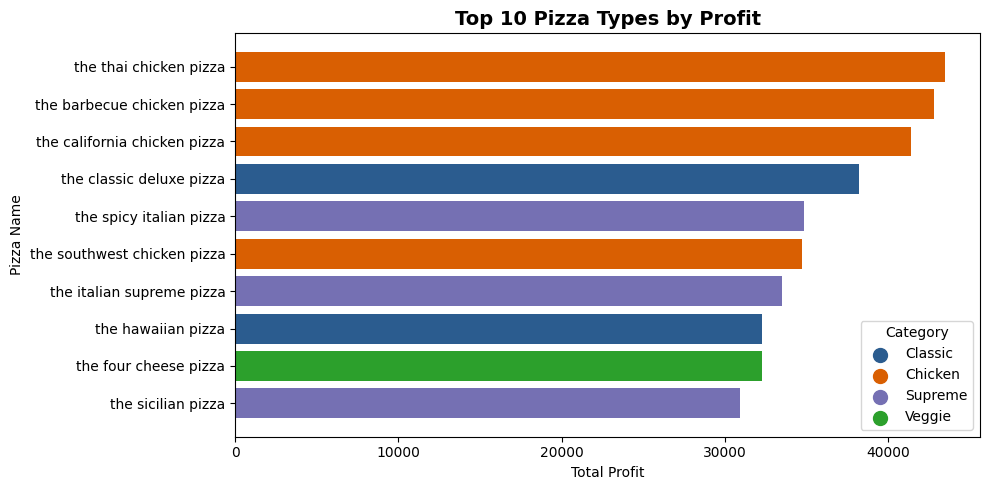

In [65]:
df_top10 = (
    df[['pizza_name', 'pizza_category', 'profit_per_type']]
    .drop_duplicates()
    .nlargest(10, 'profit_per_type')
)


colors = {
    'Classic': '#2b5c8f',
    'Chicken': '#d95f02',
    'Supreme': '#7570b3',
    'Veggie': '#2ca02c',
}

fig, ax = plt.subplots(figsize=(10, 5))


for i, row in enumerate(df_top10.itertuples()):
    ax.barh(i, row.profit_per_type, color=colors.get(row.pizza_category, 'gray'))


ax.set_yticks(range(len(df_top10)))
ax.set_yticklabels(df_top10['pizza_name'])
ax.invert_yaxis()


for category, color in colors.items():
    if category in df_top10['pizza_category'].values:
        ax.scatter([], [], color=color, label=category, s=100)

ax.legend(title='Category', loc='lower right')
ax.set_title('Top 10 Pizza Types by Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit')
ax.set_ylabel('Pizza Name')

plt.tight_layout()
plt.show()

Pizza Category order

/tmp/ipykernel_6216/1748037837.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('pizza_category')['profit_per_type']


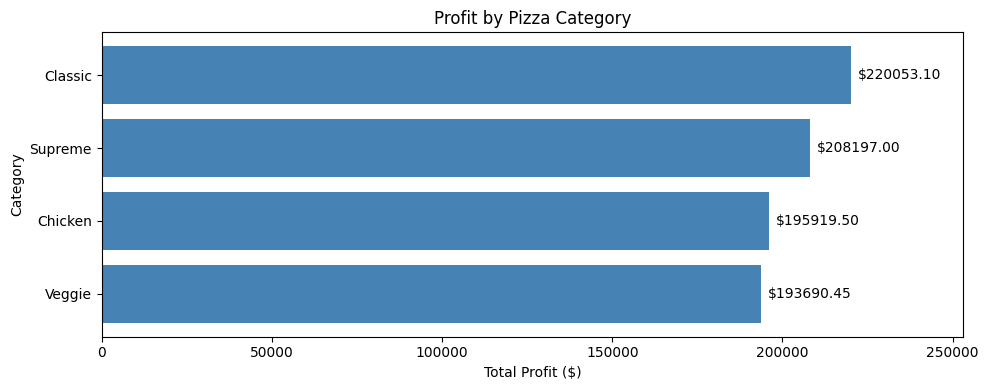

In [60]:
category_profit = (
    df[['pizza_category', 'pizza_name', 'profit_per_type']]
    .drop_duplicates()
    .groupby('pizza_category')['profit_per_type']
    .sum()
    .sort_values()
)

plt.figure(figsize=(10, 4))
bars = plt.barh(category_profit.index, category_profit.values, color='steelblue')


plt.bar_label(bars, fmt='$%1.2f', padding=5)
plt.xlim(0, category_profit.values.max() * 1.15)

plt.title('Profit by Pizza Category')
plt.xlabel('Total Profit ($)')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

How is classic category pizza is the 1st profit while most of the top 10 pizza type is chicken category ?

In [67]:
categories = df['pizza_category'].unique()
for category in categories:
  print(f"Category: {category}")
  print(df[df['pizza_category'] == category][['pizza_name', 'profit_per_type']].drop_duplicates())
  print(f"The total profit of {category} category is {df[df['pizza_category'] == category][['pizza_name', 'profit_per_type']].drop_duplicates()['profit_per_type'].sum()}")


Category: Classic
                                    pizza_name  profit_per_type
0                           the hawaiian pizza         32273.25
1                     the classic deluxe pizza         38180.50
11                             the greek pizza         28454.10
16                 the italian capocollo pizza         25094.00
28                         the pepperoni pizza         30161.75
35                          the big meat pizza         22968.00
40                        the napolitana pizza         24087.00
86  the pepperoni, mushroom, and peppers pizza         18834.50
The total profit of Classic category is 220053.1
Category: Veggie
                           pizza_name  profit_per_type
2               the five cheese pizza         26066.50
4                  the mexicana pizza         26780.75
15             the green garden pizza         13955.75
21            the spinach pesto pizza         15596.00
22  the vegetables + vegetables pizza         24374.75
39        

The Profit of each category is so close to each other what about the AVG and median ?

In [ ]:
df['pizza_category']

In [87]:
categories = df['pizza_category'].unique()
for category in categories:
  AVG = df[df['pizza_category'] == category][['pizza_name', 'profit_per_type']].drop_duplicates()['profit_per_type'].mean()
  median = df[df['pizza_category'] == category][['pizza_name', 'profit_per_type']].drop_duplicates()['profit_per_type'].median()
  print(f"Category: {category}")
  print(f"The total profit of {category} category is {df[df['pizza_category'] == category][['pizza_name', 'profit_per_type']].drop_duplicates()['profit_per_type'].sum()}")
  print(f"The AVG profit of {category} category is {AVG}")
  print(f"The Median profit of {category} category is {median}")
  print(f"the diff between Avg and median is : {AVG-median}")


Category: Classic
The total profit of Classic category is 220053.1
The AVG profit of Classic category is 27506.6375
The Median profit of Classic category is 26774.05
the diff between Avg and median is : 732.5875000000015
Category: Veggie
The total profit of Veggie category is 193690.45
The AVG profit of Veggie category is 21521.161111111112
The Median profit of Veggie category is 23271.25
the diff between Avg and median is : -1750.0888888888876
Category: Supreme
The total profit of Supreme category is 208197.0
The AVG profit of Supreme category is 23133.0
The Median profit of Supreme category is 24193.25
the diff between Avg and median is : -1060.25
Category: Chicken
The total profit of Chicken category is 195919.5
The AVG profit of Chicken category is 32653.25
The Median profit of Chicken category is 38057.625
the diff between Avg and median is : -5404.375


In [92]:
Classic_cate = df[df['pizza_category'] == 'Classic'][['pizza_name', 'profit_per_type']].drop_duplicates()
Chicken_cate = df[df['pizza_category'] == 'Chicken'][['pizza_name', 'profit_per_type']].drop_duplicates()
Supreme_cate = df[df['pizza_category'] == 'Supreme'][['pizza_name', 'profit_per_type']].drop_duplicates()
Veggie_cate = df[df['pizza_category'] == 'Veggie'][['pizza_name', 'profit_per_type']].drop_duplicates()

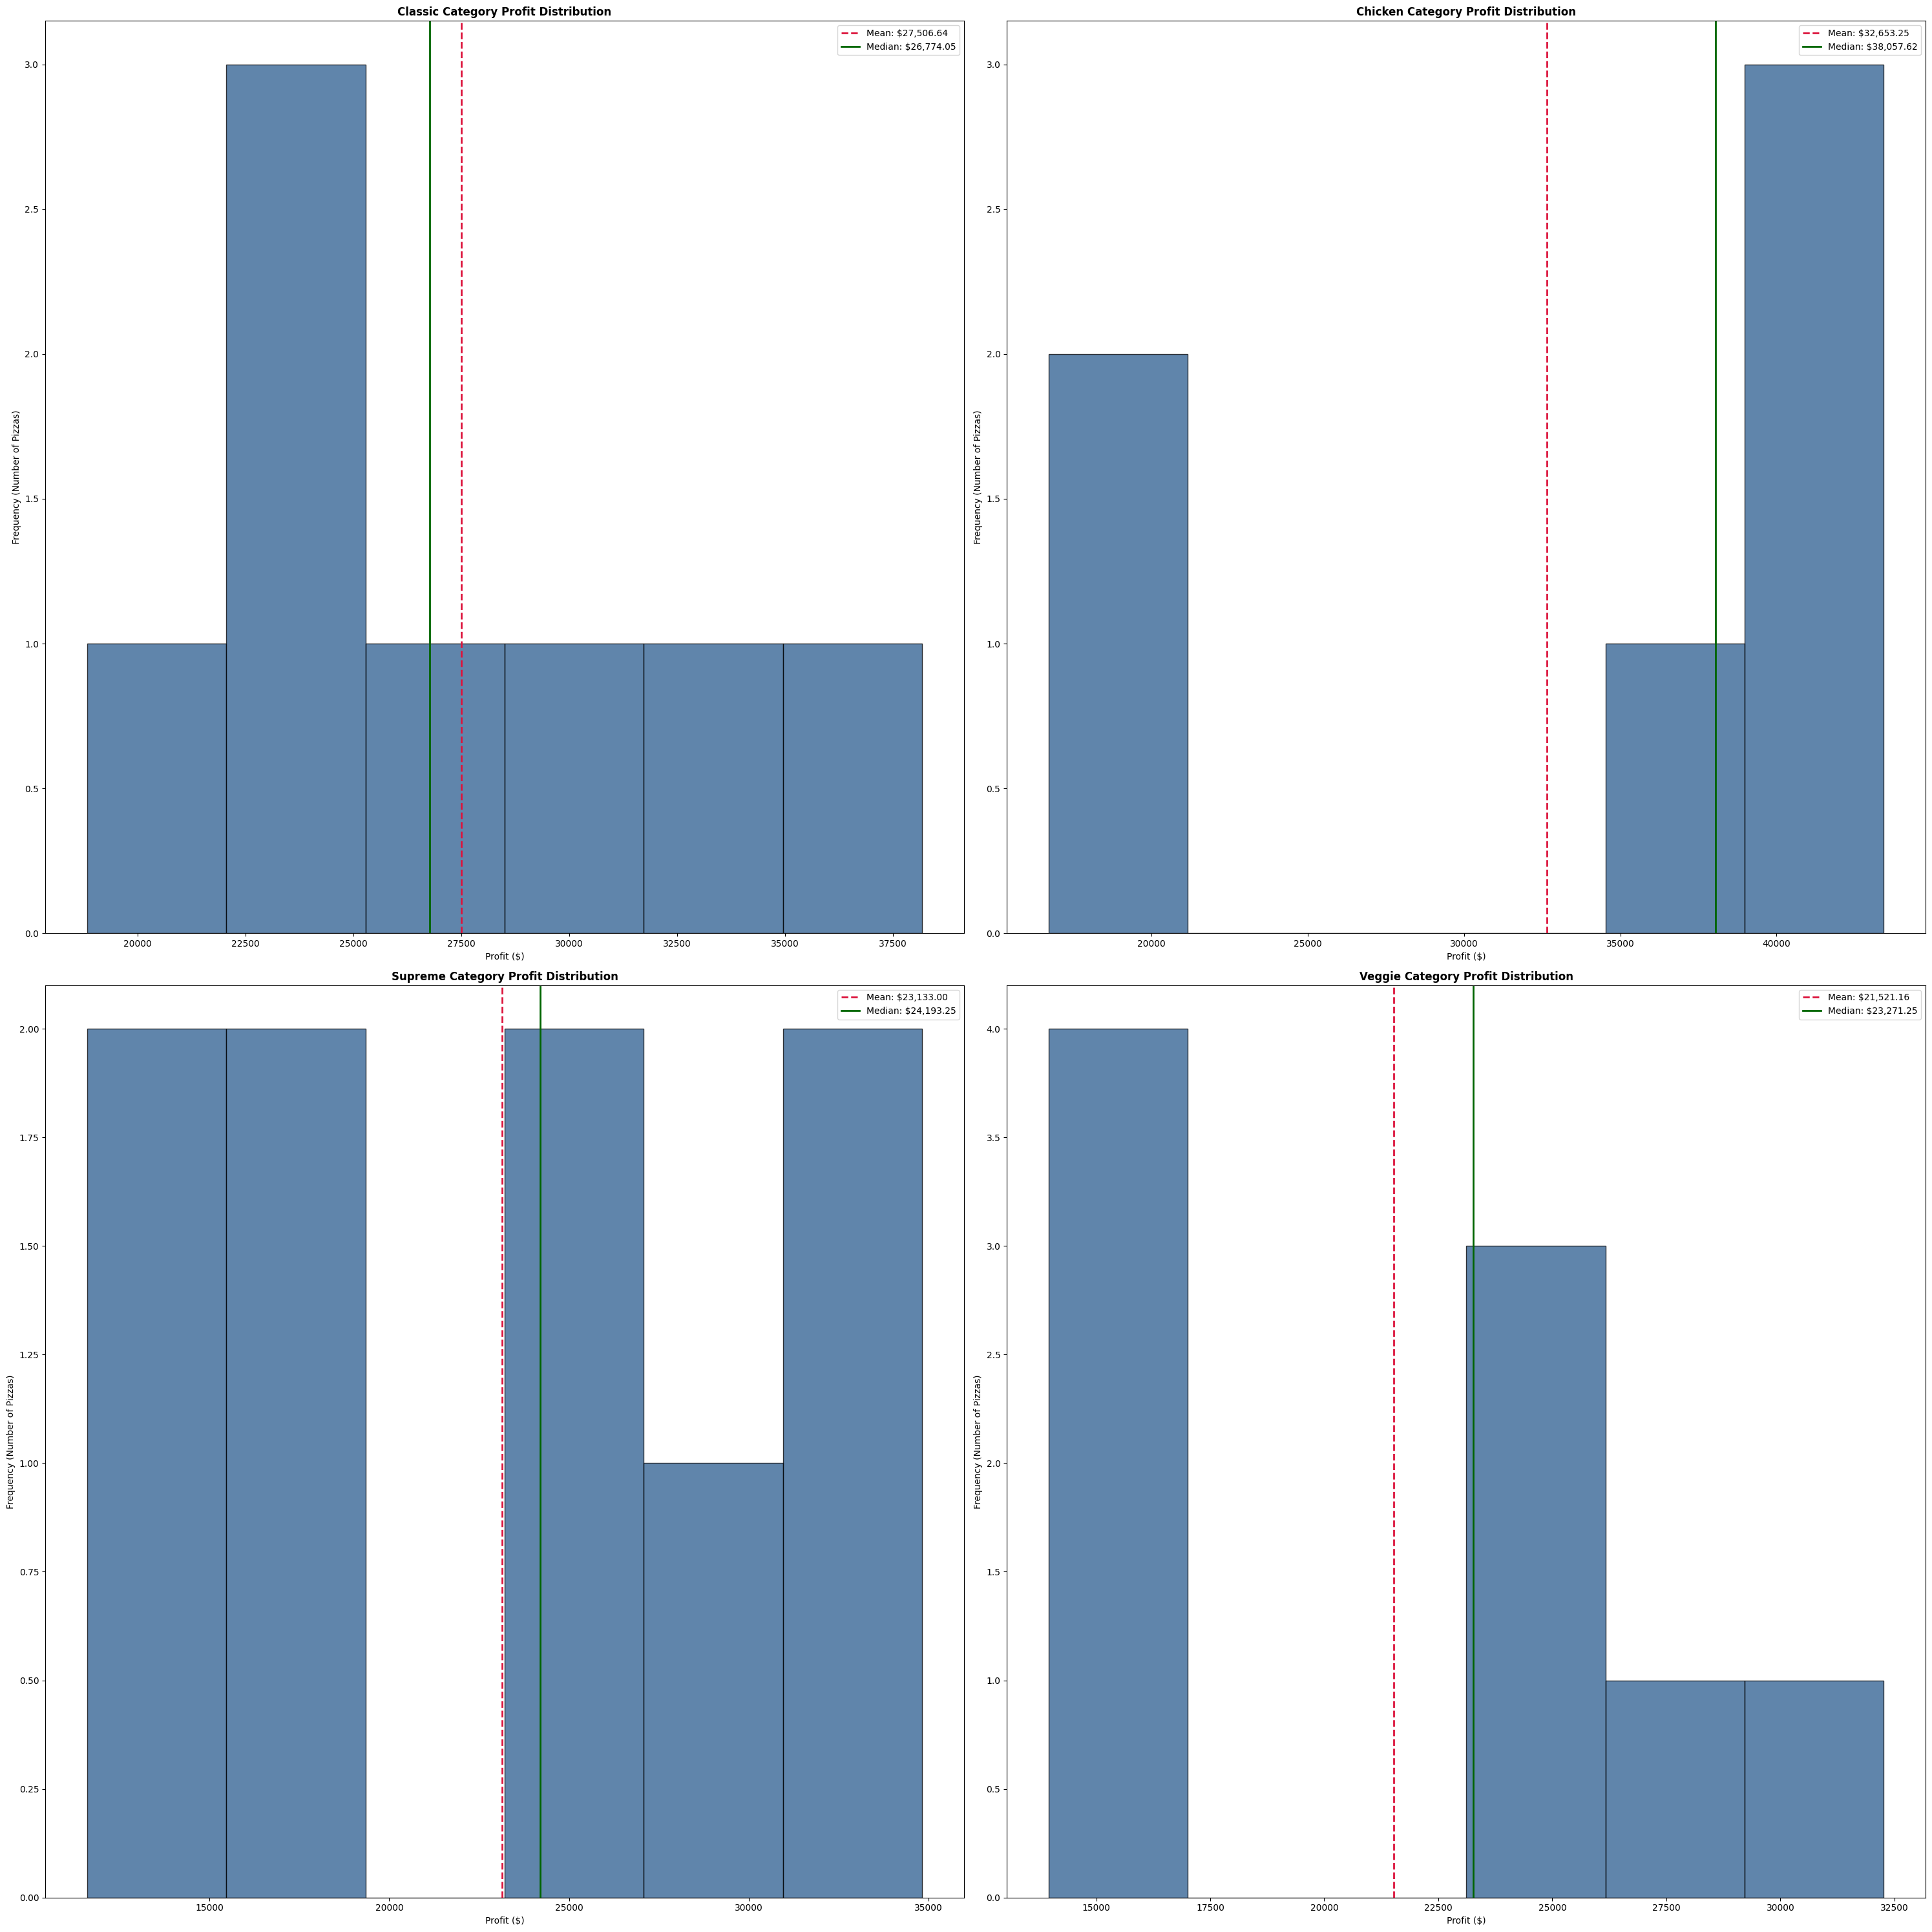

In [109]:
categories = [
    ('Classic', Classic_cate),
    ('Chicken', Chicken_cate),
    ('Supreme', Supreme_cate),
    ('Veggie', Veggie_cate),
]


fig, axes = plt.subplots(2, 2, figsize=(30, 30))
axes = axes.flatten()


for i, (title, category_df) in enumerate(categories):
    ax = axes[i]
    profits = category_df['profit_per_type']


    mean_val = profits.mean()
    median_val = profits.median()

    ax.hist(
        profits, bins=6, color='#2b5c8f', alpha=0.75, edgecolor='black'
    )


    ax.axvline(
        mean_val,
        color='crimson',
        linestyle='--',
        linewidth=2,
        label=f'Mean: ${mean_val:,.2f}',
    )
    ax.axvline(
        median_val,
        color='darkgreen',
        linestyle='-',
        linewidth=2,
        label=f'Median: ${median_val:,.2f}',
    )


    ax.set_title(
        f'{title} Category Profit Distribution', fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Profit ($)', fontsize=10)
    ax.set_ylabel('Frequency (Number of Pizzas)', fontsize=10)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

- This Means that the Chicken , supreme and veggie categories are low performing in general and they have few pizzas that are doing well , that explain why top 3 performing pizza types belong to the chicken category but the chicken category is not performing well in general.

- The classic type is mostly follow normal distribution that's with a little bit of right skew behavior , this why it is the top 1 pizza category because a lot of it's pizza types are performing well.

In [114]:
df[df['pizza_category'] == 'Classic'][['pizza_name', 'profit_per_type']].drop_duplicates().sort_values(by='profit_per_type' , ascending=False)

,pizza_name,profit_per_type
1,the classic deluxe pizza,38180.50
0,the hawaiian pizza,32273.25
28,the pepperoni pizza,30161.75
11,the greek pizza,28454.10
16,the italian capocollo pizza,25094.00
40,the napolitana pizza,24087.00
35,the big meat pizza,22968.00
86,"the pepperoni, mushroom, and peppers pizza",18834.50
